# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# Extract Dataset

In [2]:
zip_path = "/content/mask.zip"
extract_path = "/content/facemask"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Extraction completed!")


Extraction completed!


In [3]:
!ls

 face	    Face_Mask_model.h5	'Manan (2).jpg'   mask.jpg   sample_data
 facemask   face.zip		 manan.jpg	  mask.zip


In [4]:
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

# Print Specific Images

In [5]:
with_mask_files = os.listdir('/content/facemask/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_639.jpg', 'with_mask_3572.jpg', 'with_mask_2007.jpg', 'with_mask_2163.jpg', 'with_mask_410.jpg']
['with_mask_2486.jpg', 'with_mask_3641.jpg', 'with_mask_395.jpg', 'with_mask_3374.jpg', 'with_mask_2552.jpg']


In [6]:
without_mask_files = os.listdir('/content/facemask/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1280.jpg', 'without_mask_2148.jpg', 'without_mask_295.jpg', 'without_mask_1820.jpg', 'without_mask_3776.jpg']
['without_mask_2363.jpg', 'without_mask_3379.jpg', 'without_mask_619.jpg', 'without_mask_3368.jpg', 'without_mask_1931.jpg']


# Total Images

In [7]:
print('Number Of Mask Images:', len(with_mask_files))
print('Number Of Without Mask Images:', len(without_mask_files))

Number Of Mask Images: 3725
Number Of Without Mask Images: 3828


# Create The labels

In [8]:
with_mask_label = [1]*3725
without_mask_label = [0]*3828

print(with_mask_label[0:5])

print(without_mask_label[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [9]:
print(len(with_mask_label))
print(len(without_mask_label))

3725
3828


In [10]:
labels = with_mask_label + without_mask_label

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


# Show Mask Image

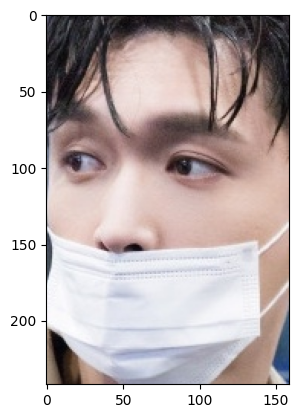

In [11]:
img = mpimg.imread('/content/facemask/data/with_mask/with_mask_1009.jpg')
imgplot  = plt.imshow(img)
plt.show()

# Show Without Mask Image

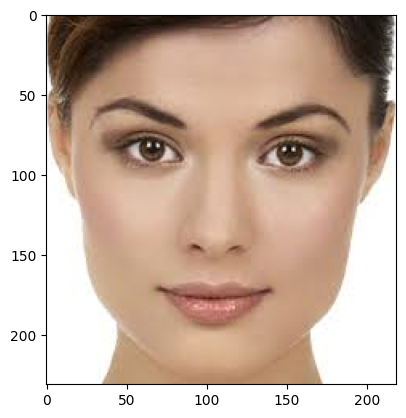

In [12]:
img = mpimg.imread('/content/facemask/data/without_mask/without_mask_1004.jpg')
imgplot  = plt.imshow(img)
plt.show()

In [13]:
import numpy as np

# Convert Images into Numpy Array

In [14]:
with_mask_path = '/content/facemask/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)


without_mask_path = '/content/facemask/data/without_mask/'

for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [15]:
X = np.array(data)
Y = np.array(labels)
type(X)

numpy.ndarray

In [16]:
type(Y)

numpy.ndarray

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=.2, random_state=2)
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [18]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [19]:
X_train[[0]]

array([[[[235, 235, 227],
         [235, 235, 227],
         [235, 235, 227],
         ...,
         [219, 219, 209],
         [218, 218, 208],
         [217, 217, 207]],

        [[235, 235, 227],
         [235, 235, 227],
         [235, 235, 227],
         ...,
         [219, 219, 209],
         [218, 218, 208],
         [217, 217, 207]],

        [[235, 235, 227],
         [235, 235, 227],
         [235, 235, 227],
         ...,
         [219, 219, 209],
         [218, 218, 208],
         [217, 217, 207]],

        ...,

        [[208, 208, 200],
         [208, 208, 200],
         [209, 209, 201],
         ...,
         [120, 117, 116],
         [111, 110, 108],
         [109, 109, 107]],

        [[207, 207, 199],
         [208, 208, 200],
         [208, 208, 200],
         ...,
         [118, 114, 113],
         [113, 111, 110],
         [ 97,  97,  95]],

        [[207, 207, 199],
         [207, 207, 199],
         [208, 208, 200],
         ...,
         [111, 108, 109],
        

# Build A CNN Model

In [20]:
import tensorflow as tf
from tensorflow import keras

In [21]:
model = keras.Sequential()

In [22]:
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model

In [23]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])

In [24]:
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 142s 822ms/step - acc: 0.7213 - loss: 0.5369 - val_acc: 0.8727 - val_loss: 0.3026
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 140s 811ms/step - acc: 0.8768 - loss: 0.3001 - val_acc: 0.8678 - val_loss: 0.2936
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 137s 783ms/step - acc: 0.8908 - loss: 0.2657 - val_acc: 0.8959 - val_loss: 0.2301
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 148s 824ms/step - acc: 0.9230 - loss: 0.1926 - val_acc: 0.9091 - val_loss: 0.2261
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 139s 805ms/step - acc: 0.9373 - loss: 0.1600 - val_acc: 0.8926 - val_loss: 0.2593
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 139s 815ms/step - acc: 0.9369 - loss: 0.1569 - val_acc: 0.9140 - val_loss: 0.2463
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 135s 795ms/step - acc: 0.9526 - loss: 0.1209 - val_acc: 0.9207 - val_loss: 0.2499
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 135s 797ms/step - acc: 0.9635 - loss: 0.1072 - val_acc: 0.8975 - val_loss: 0.3498
Epoch 9/10
170/170 ━━━━━

# Test Accuracy

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test accuracy =', accuracy)

# Accuracy And Loss Visualization

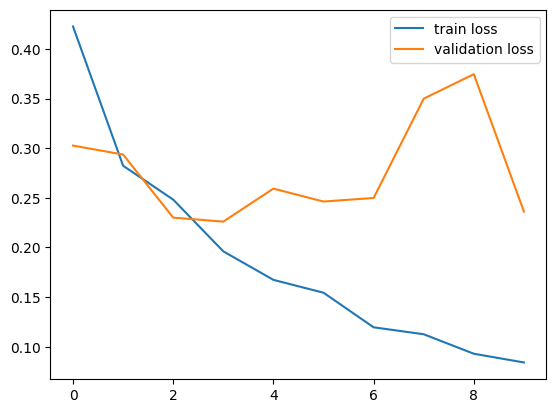

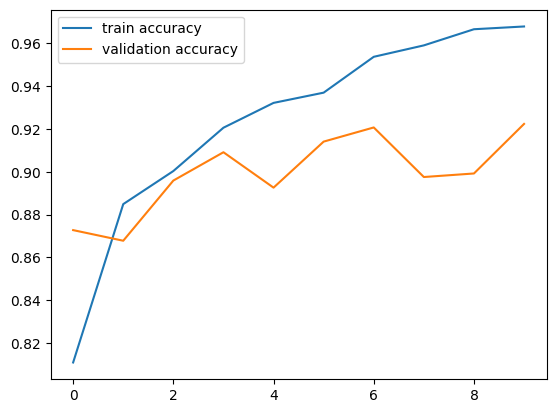

In [30]:
h = history
#plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

#plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


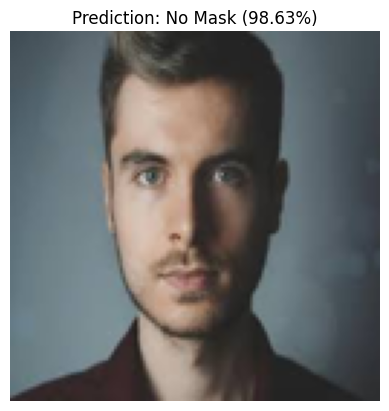

In [41]:
from tensorflow.keras.models import load_model

model = load_model("Face_Mask_model.h5")
predict_image("person.jpeg", model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


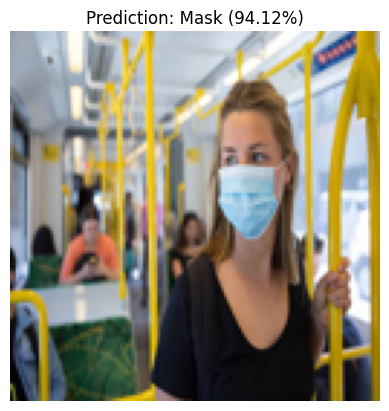

In [35]:
predict_image("mask4.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


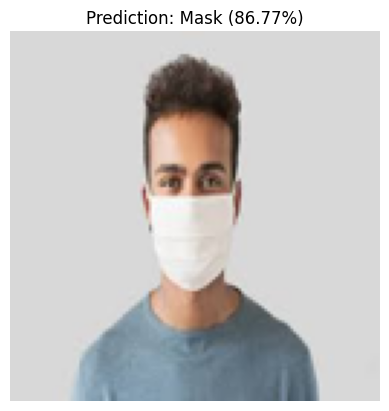

In [37]:
predict_image("mask.jpeg", model)

# Model Save

In [27]:
model=model.save("Face_Mask_model.h5")